# Clustering Analysis: Flight Delay Pattern Archetypes

**Goal**: Group airports and airlines into behavioral clusters based on delay patterns using KMeans.  
**Data**: Reads `dataset/cleaned_flight_data.csv` from preprocessing pipeline.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
os.makedirs('outputs/models', exist_ok=True)
os.makedirs('outputs/figures', exist_ok=True)
os.makedirs('outputs/tables', exist_ok=True)

RANDOM_STATE = 42

In [2]:
df = pd.read_csv('dataset/cleaned_flight_data.csv')
print(f'Loaded: {df.shape}')

Loaded: (135293, 34)


## Build Airport-Level Feature Matrix
Aggregate per airport: delay rate, cancellation rate, avg delay severity, flight volume, and delay cause shares.

In [3]:
delay_cause_cols = ['carrier_delay_minutes', 'weather_delay_minutes', 'nas_delay_minutes',
                     'security_delay_minutes', 'late_aircraft_delay_minutes']

def build_entity_features(df, group_cols):
    """Aggregate to entity level with clustering features."""
    agg = df.groupby(group_cols).agg(
        total_flights=('total_flights', 'sum'),
        delayed_flights=('delayed_flights', 'sum'),
        cancelled_flights=('cancelled_flights', 'sum'),
        total_delay_min=('total_delay_minutes', 'sum'),
        carrier_delay_min=('carrier_delay_minutes', 'sum'),
        weather_delay_min=('weather_delay_minutes', 'sum'),
        nas_delay_min=('nas_delay_minutes', 'sum'),
        security_delay_min=('security_delay_minutes', 'sum'),
        late_aircraft_delay_min=('late_aircraft_delay_minutes', 'sum')
    ).reset_index()
    
    agg['delay_rate'] = agg['delayed_flights'] / agg['total_flights']
    agg['cancellation_rate'] = agg['cancelled_flights'] / agg['total_flights']
    agg['avg_delay_severity'] = agg['total_delay_min'] / agg['delayed_flights'].replace(0, 1)
    
    # Delay cause shares
    total_cause = agg[['carrier_delay_min','weather_delay_min','nas_delay_min',
                        'security_delay_min','late_aircraft_delay_min']].sum(axis=1).replace(0, np.nan)
    agg['carrier_share'] = (agg['carrier_delay_min'] / total_cause).fillna(0)
    agg['weather_share'] = (agg['weather_delay_min'] / total_cause).fillna(0)
    agg['nas_share'] = (agg['nas_delay_min'] / total_cause).fillna(0)
    agg['late_aircraft_share'] = (agg['late_aircraft_delay_min'] / total_cause).fillna(0)
    
    return agg

airport_feat = build_entity_features(df, ['airport', 'airport_full_name'])
airline_feat = build_entity_features(df, ['carrier', 'airline'])

print(f'Airport features: {airport_feat.shape}')
print(f'Airline features: {airline_feat.shape}')

Airport features: (424, 18)
Airline features: (26, 18)



## Optimal K Selection
Use silhouette score and elbow method to find the best number of clusters.

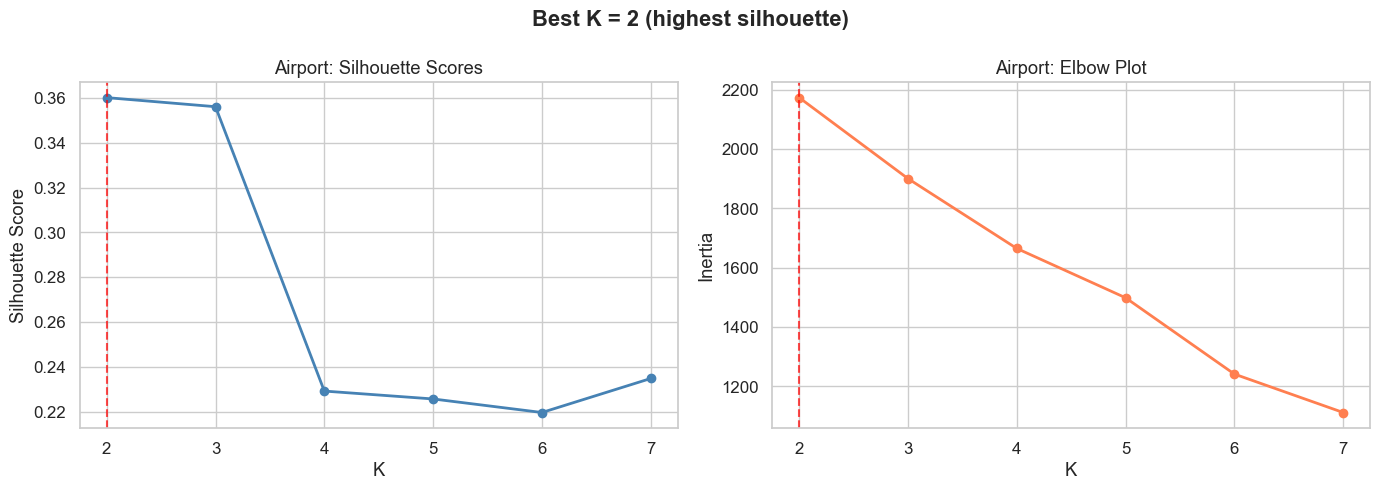


Optimal K for airports: 2


In [4]:
CLUSTER_FEATURES = ['delay_rate', 'cancellation_rate', 'avg_delay_severity',
                     'carrier_share', 'weather_share', 'nas_share', 'late_aircraft_share']

def find_optimal_k(data, features, entity_name, k_range=range(2, 8)):
    """Evaluate K values using silhouette score and inertia."""
    X = data[features].values
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    results = []
    for k in k_range:
        km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
        labels = km.fit_predict(X_scaled)
        results.append({
            'k': k,
            'silhouette': silhouette_score(X_scaled, labels),
            'inertia': km.inertia_
        })
    
    res_df = pd.DataFrame(results)
    best_k = res_df.loc[res_df['silhouette'].idxmax(), 'k']
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    axes[0].plot(res_df['k'], res_df['silhouette'], 'o-', color='steelblue', linewidth=2)
    axes[0].axvline(x=best_k, color='red', linestyle='--', alpha=0.7)
    axes[0].set_xlabel('K')
    axes[0].set_ylabel('Silhouette Score')
    axes[0].set_title(f'{entity_name}: Silhouette Scores')
    
    axes[1].plot(res_df['k'], res_df['inertia'], 'o-', color='coral', linewidth=2)
    axes[1].axvline(x=best_k, color='red', linestyle='--', alpha=0.7)
    axes[1].set_xlabel('K')
    axes[1].set_ylabel('Inertia')
    axes[1].set_title(f'{entity_name}: Elbow Plot')
    
    plt.suptitle(f'Best K = {int(best_k)} (highest silhouette)', fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'outputs/figures/{entity_name.lower()}_k_selection.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    res_df.to_csv(f'outputs/tables/{entity_name.lower()}_k_selection.csv', index=False)
    return int(best_k), scaler

airport_best_k, airport_scaler = find_optimal_k(airport_feat, CLUSTER_FEATURES, 'Airport')
print(f'\nOptimal K for airports: {airport_best_k}')

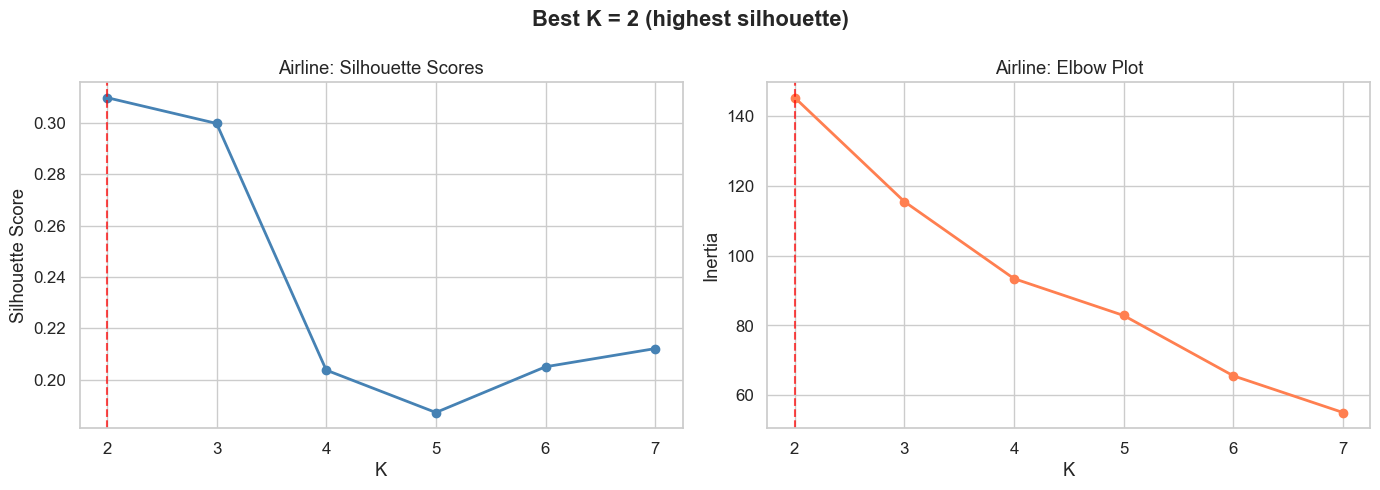

Optimal K for airlines: 2


In [5]:
airline_best_k, airline_scaler = find_optimal_k(airline_feat, CLUSTER_FEATURES, 'Airline')
print(f'Optimal K for airlines: {airline_best_k}')


## Run KMeans Clustering

In [6]:
def run_clustering(data, features, scaler, best_k, entity_name):
    """Fit KMeans, assign cluster labels, and produce summary."""
    X_scaled = scaler.transform(data[features].values)
    
    km = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
    data = data.copy()
    data['cluster'] = km.fit_predict(X_scaled)
    
    # Cluster summary
    summary = data.groupby('cluster')[features + ['total_flights']].agg(['mean', 'count']).round(4)
    summary.columns = ['_'.join(col) for col in summary.columns]
    
    # Simpler summary for display
    display_summary = data.groupby('cluster').agg(
        n_entities=('cluster', 'size'),
        avg_delay_rate=('delay_rate', 'mean'),
        avg_cancel_rate=('cancellation_rate', 'mean'),
        avg_severity_min=('avg_delay_severity', 'mean'),
        total_flights=('total_flights', 'sum'),
        avg_carrier_share=('carrier_share', 'mean'),
        avg_weather_share=('weather_share', 'mean'),
        avg_late_aircraft_share=('late_aircraft_share', 'mean')
    ).round(4)
    
    # Save
    data.to_csv(f'outputs/tables/{entity_name.lower()}_clustered.csv', index=False)
    display_summary.to_csv(f'outputs/tables/{entity_name.lower()}_cluster_summary.csv')
    joblib.dump(km, f'outputs/models/{entity_name.lower()}_kmeans.pkl')
    joblib.dump(scaler, f'outputs/models/{entity_name.lower()}_scaler.pkl')
    
    print(f'{entity_name} clustering complete — {best_k} clusters')
    return data, display_summary, km

airport_clustered, airport_summary, airport_km = run_clustering(
    airport_feat, CLUSTER_FEATURES, airport_scaler, airport_best_k, 'Airport')

print('\nAirport Cluster Profiles:')
airport_summary

Airport clustering complete — 2 clusters

Airport Cluster Profiles:


,n_entities,avg_delay_rate,avg_cancel_rate,avg_severity_min,total_flights,avg_carrier_share,avg_weather_share,avg_late_aircraft_share
cluster,,,,,,,,
0,115,0.1621,0.0277,90.2170,1387048.0,0.5449,0.1717,0.2087
1,309,0.1847,0.0261,66.6252,39523205.0,0.3629,0.0861,0.3951


In [7]:
airline_clustered, airline_summary, airline_km = run_clustering(
    airline_feat, CLUSTER_FEATURES, airline_scaler, airline_best_k, 'Airline')

print('\nAirline Cluster Profiles:')
airline_summary

Airline clustering complete — 2 clusters

Airline Cluster Profiles:


,n_entities,avg_delay_rate,avg_cancel_rate,avg_severity_min,total_flights,avg_carrier_share,avg_weather_share,avg_late_aircraft_share
cluster,,,,,,,,
0,4,0.1183,0.0762,66.2343,91997.0,0.3055,0.0395,0.4349
1,22,0.1890,0.0246,73.1376,40818256.0,0.3390,0.0649,0.4004


## Interpret Airport Clusters
Label each cluster archetype based on its delay behavior profile.

In [9]:
def label_clusters(summary_df, entity_name):
    """Auto-label clusters based on delay rate and severity."""
    labels = {}
    for cluster_id in summary_df.index:
        row = summary_df.loc[cluster_id]
        dr = row['avg_delay_rate']
        sev = row['avg_severity_min']
        vol = row['total_flights']
        
        # Build descriptive label
        parts = []
        if dr > summary_df['avg_delay_rate'].median():
            parts.append('High-Delay')
        else:
            parts.append('Low-Delay')
        
        if sev > summary_df['avg_severity_min'].median():
            parts.append('High-Severity')
        else:
            parts.append('Low-Severity')
        
        if vol > summary_df['total_flights'].median():
            parts.append('High-Volume')
        else:
            parts.append('Low-Volume')
        
        labels[cluster_id] = ' / '.join(parts)
    
    return labels

airport_labels = label_clusters(airport_summary, 'Airport')
print('Airport Cluster Archetypes:')
for k, v in airport_labels.items():
    n = airport_summary.loc[k, 'n_entities']
    dr = airport_summary.loc[k, 'avg_delay_rate'] * 100
    print(f'  Cluster {k} ({n} airports): {v}  [delay rate: {dr:.1f}%]')

Airport Cluster Archetypes:
  Cluster 0 (115 airports): Low-Delay / High-Severity / Low-Volume  [delay rate: 16.2%]
  Cluster 1 (309 airports): High-Delay / Low-Severity / High-Volume  [delay rate: 18.5%]


In [10]:
airline_labels = label_clusters(airline_summary, 'Airline')
print('Airline Cluster Archetypes:')
for k, v in airline_labels.items():
    n = airline_summary.loc[k, 'n_entities']
    dr = airline_summary.loc[k, 'avg_delay_rate'] * 100
    print(f'  Cluster {k} ({n} airlines): {v}  [delay rate: {dr:.1f}%]')

Airline Cluster Archetypes:
  Cluster 0 (4 airlines): Low-Delay / Low-Severity / Low-Volume  [delay rate: 11.8%]
  Cluster 1 (22 airlines): High-Delay / High-Severity / High-Volume  [delay rate: 18.9%]


## Cluster Visualization

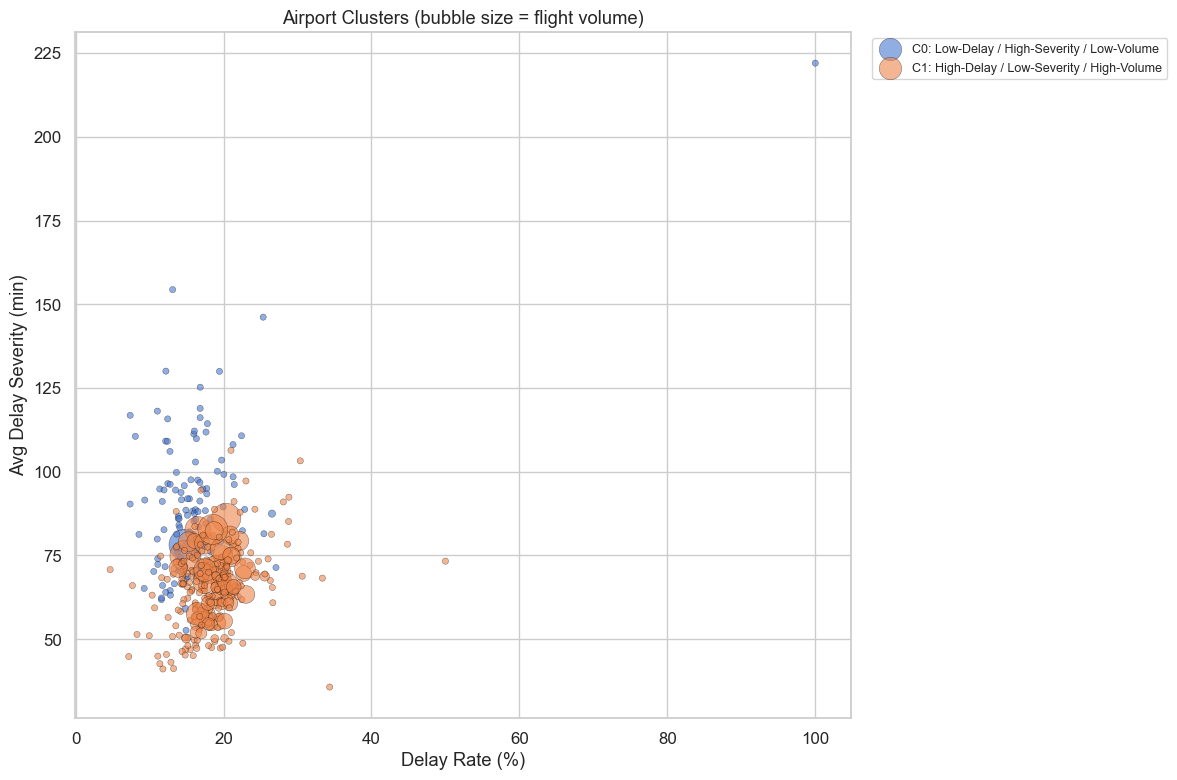

In [11]:
def plot_cluster_scatter(data, x_col, y_col, size_col, entity_name, labels_dict):
    """2D scatter colored by cluster with size = flight volume."""
    fig, ax = plt.subplots(figsize=(12, 8))
    
    for cluster_id in sorted(data['cluster'].unique()):
        subset = data[data['cluster'] == cluster_id]
        ax.scatter(
            subset[x_col] * 100, subset[y_col],
            s=np.clip(subset[size_col] / subset[size_col].max() * 500, 20, 500),
            alpha=0.6, label=f'C{cluster_id}: {labels_dict[cluster_id]}',
            edgecolors='black', linewidth=0.3
        )
    
    ax.set_xlabel('Delay Rate (%)')
    ax.set_ylabel('Avg Delay Severity (min)')
    ax.set_title(f'{entity_name} Clusters (bubble size = flight volume)')
    ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
    plt.tight_layout()
    plt.savefig(f'outputs/figures/{entity_name.lower()}_cluster_scatter.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_cluster_scatter(airport_clustered, 'delay_rate', 'avg_delay_severity', 'total_flights', 'Airport', airport_labels)

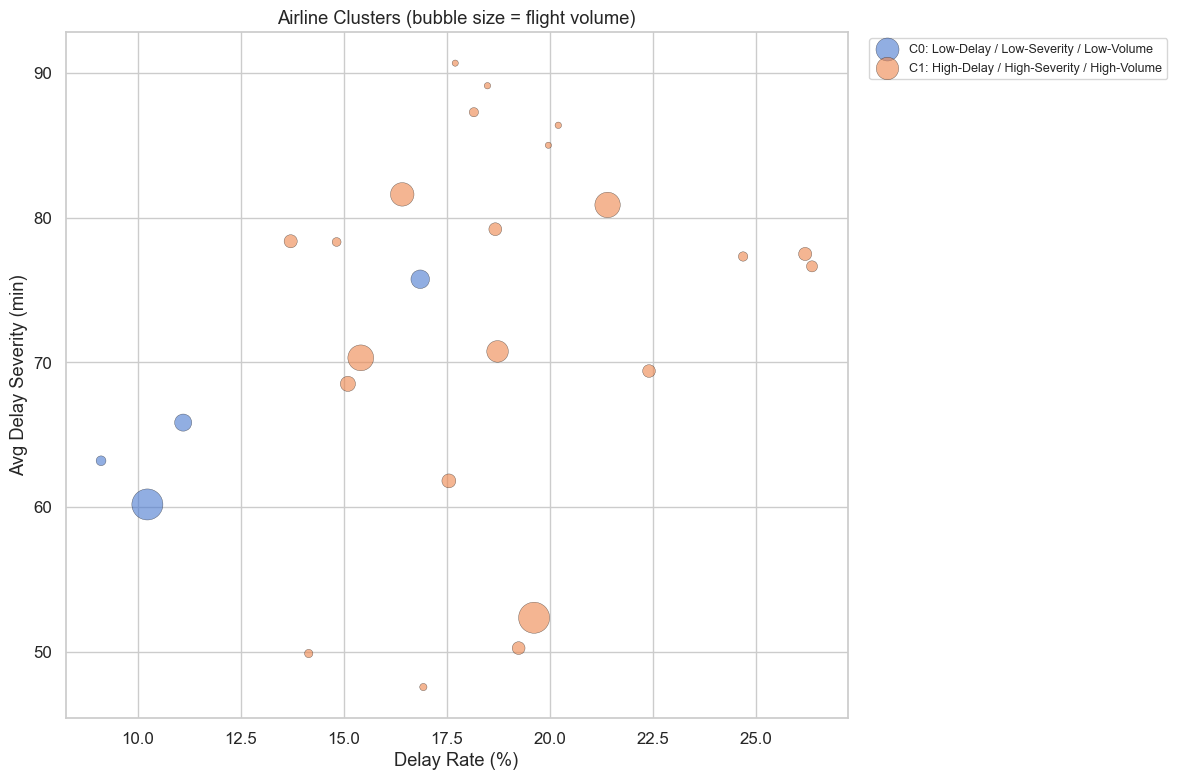

In [12]:
plot_cluster_scatter(airline_clustered, 'delay_rate', 'avg_delay_severity', 'total_flights', 'Airline', airline_labels)

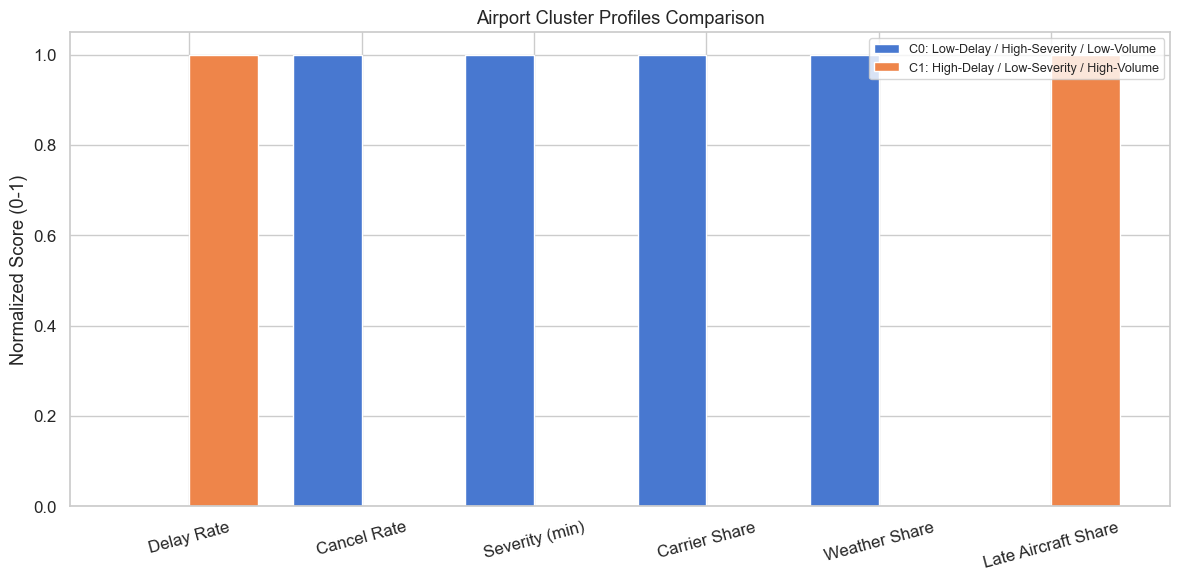

In [13]:
# Cluster profile radar/comparison chart
def plot_cluster_profiles(summary_df, entity_name, labels_dict):
    """Compare clusters across key metrics."""
    metrics = ['avg_delay_rate', 'avg_cancel_rate', 'avg_severity_min',
               'avg_carrier_share', 'avg_weather_share', 'avg_late_aircraft_share']
    metric_labels = ['Delay Rate', 'Cancel Rate', 'Severity (min)',
                     'Carrier Share', 'Weather Share', 'Late Aircraft Share']
    
    # Normalize for comparison
    plot_data = summary_df[metrics].copy()
    plot_data = (plot_data - plot_data.min()) / (plot_data.max() - plot_data.min() + 1e-10)
    plot_data.columns = metric_labels
    
    fig, ax = plt.subplots(figsize=(12, 6))
    x = np.arange(len(metric_labels))
    width = 0.8 / len(plot_data)
    
    for i, (cluster_id, row) in enumerate(plot_data.iterrows()):
        ax.bar(x + i * width, row.values, width, label=f'C{cluster_id}: {labels_dict[cluster_id]}')
    
    ax.set_xticks(x + width * (len(plot_data) - 1) / 2)
    ax.set_xticklabels(metric_labels, rotation=15)
    ax.set_ylabel('Normalized Score (0-1)')
    ax.set_title(f'{entity_name} Cluster Profiles Comparison')
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.savefig(f'outputs/figures/{entity_name.lower()}_cluster_profiles.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_cluster_profiles(airport_summary, 'Airport', airport_labels)

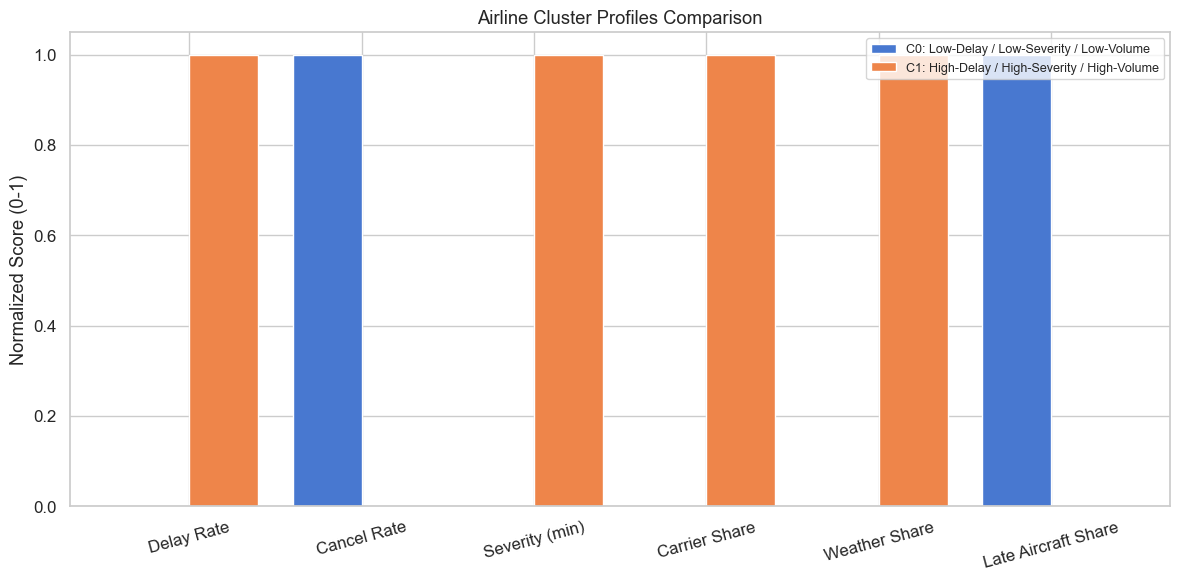

In [14]:
plot_cluster_profiles(airline_summary, 'Airline', airline_labels)

## Identify Notable Members in Each Cluster
Which specific airports/airlines belong to the worst and best clusters?

In [15]:
# Worst airport cluster (highest delay rate)
worst_cluster = airport_summary['avg_delay_rate'].idxmax()
best_cluster = airport_summary['avg_delay_rate'].idxmin()

print(f'=== WORST Airport Cluster (C{worst_cluster}: {airport_labels[worst_cluster]}) ===')
worst_airports = airport_clustered[airport_clustered['cluster'] == worst_cluster].nlargest(15, 'total_flights')
print(worst_airports[['airport', 'airport_full_name', 'total_flights', 'delay_rate', 'avg_delay_severity']].to_string(index=False))

print(f'\n=== BEST Airport Cluster (C{best_cluster}: {airport_labels[best_cluster]}) ===')
best_airports = airport_clustered[airport_clustered['cluster'] == best_cluster].nlargest(15, 'total_flights')
print(best_airports[['airport', 'airport_full_name', 'total_flights', 'delay_rate', 'avg_delay_severity']].to_string(index=False))

=== WORST Airport Cluster (C1: High-Delay / Low-Severity / High-Volume) ===
airport                                      airport_full_name  total_flights  delay_rate  avg_delay_severity
    ATL  Atlanta, GA: Hartsfield-Jackson Atlanta International      1914971.0    0.148550           74.922329
    ORD              Chicago, IL: Chicago O'Hare International      1778590.0    0.185501           82.767021
    DFW Dallas/Fort Worth, TX: Dallas/Fort Worth International      1705415.0    0.203679           86.184821
    DEN                       Denver, CO: Denver International      1682968.0    0.189568           70.556230
    CLT         Charlotte, NC: Charlotte Douglas International      1347494.0    0.165458           82.701903
    LAX             Los Angeles, CA: Los Angeles International      1086362.0    0.174383           67.159721
    SEA              Seattle, WA: Seattle/Tacoma International      1026130.0    0.165002           57.525429
    PHX          Phoenix, AZ: Phoenix Sky Ha

In [16]:
# Airline cluster members
for c in sorted(airline_clustered['cluster'].unique()):
    print(f'\n=== Airline Cluster {c}: {airline_labels[c]} ===')
    members = airline_clustered[airline_clustered['cluster'] == c].sort_values('total_flights', ascending=False)
    print(members[['carrier', 'airline', 'total_flights', 'delay_rate', 'avg_delay_severity']].to_string(index=False))


=== Airline Cluster 0: Low-Delay / Low-Severity / Low-Volume ===
carrier                 airline  total_flights  delay_rate  avg_delay_severity
     EV ExpressJet Airlines LLC        52212.0    0.102352           60.173091
     AX   Trans States Airlines        18705.0    0.168511           75.740482
     CP        Compass Airlines        15878.0    0.111034           65.831537
     EM    Empire Airlines Inc.         5202.0    0.091119           63.191983

=== Airline Cluster 1: High-Delay / High-Severity / High-Volume ===
carrier                                   airline  total_flights  delay_rate  avg_delay_severity
     WN                        Southwest Airlines      7582834.0    0.196119           52.340814
     DL                   Delta Air Lines Network      5242763.0    0.154091           70.307866
     AA                 American Airlines Network      5078840.0    0.213933           80.876425
     OO                     SkyWest Airlines Inc.      4343633.0    0.164146      


## Delay Cause Fingerprint by Cluster
What makes each cluster different in terms of *why* delays happen?

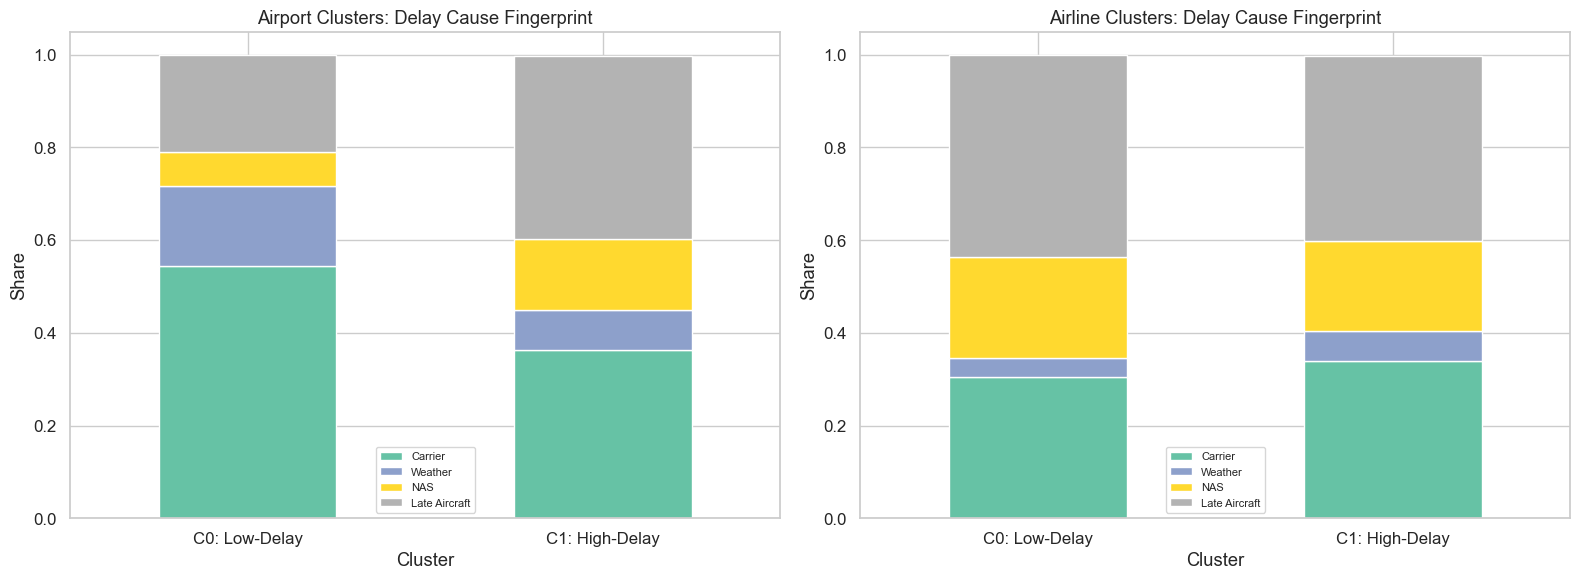

In [17]:
cause_shares = ['carrier_share', 'weather_share', 'nas_share', 'late_aircraft_share']
cause_labels = ['Carrier', 'Weather', 'NAS', 'Late Aircraft']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for idx, (entity_data, entity_name, label_dict) in enumerate([
    (airport_clustered, 'Airport', airport_labels),
    (airline_clustered, 'Airline', airline_labels)
]):
    cluster_causes = entity_data.groupby('cluster')[cause_shares].mean()
    cluster_causes.columns = cause_labels
    
    cluster_causes.plot(kind='bar', stacked=True, ax=axes[idx], colormap='Set2')
    axes[idx].set_title(f'{entity_name} Clusters: Delay Cause Fingerprint')
    axes[idx].set_ylabel('Share')
    axes[idx].set_xlabel('Cluster')
    new_labels = [f'C{c}: {label_dict[c].split(" / ")[0]}' for c in cluster_causes.index]
    axes[idx].set_xticklabels(new_labels, rotation=0)
    axes[idx].legend(fontsize=8)

plt.tight_layout()
plt.savefig('outputs/figures/cluster_cause_fingerprint.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
print('CLUSTERING ANALYSIS — KEY FINDINGS')


print(f'\nAIRPORT CLUSTERING ({airport_best_k} clusters):')
for c in sorted(airport_labels.keys()):
    row = airport_summary.loc[c]
    print(f'  C{c} — {airport_labels[c]}')
    print(f'       {int(row["n_entities"])} airports | {row["avg_delay_rate"]*100:.1f}% delay rate | '
          f'{row["avg_severity_min"]:.0f} min avg severity | {int(row["total_flights"]):,} flights')

print(f'\nAIRLINE CLUSTERING ({airline_best_k} clusters):')
for c in sorted(airline_labels.keys()):
    row = airline_summary.loc[c]
    print(f'  C{c} — {airline_labels[c]}')
    print(f'       {int(row["n_entities"])} airlines | {row["avg_delay_rate"]*100:.1f}% delay rate | '
          f'{row["avg_severity_min"]:.0f} min avg severity | {int(row["total_flights"]):,} flights')

print(f'\nSaved artifacts:')
print('  Models: outputs/models/airport_kmeans.pkl, airline_kmeans.pkl')
print('  Tables: outputs/tables/airport_clustered.csv, airline_clustered.csv')
print('  Figures: outputs/figures/*_cluster_*.png')

CLUSTERING ANALYSIS — KEY FINDINGS

AIRPORT CLUSTERING (2 clusters):
  C0 — Low-Delay / High-Severity / Low-Volume
       115 airports | 16.2% delay rate | 90 min avg severity | 1,387,048 flights
  C1 — High-Delay / Low-Severity / High-Volume
       309 airports | 18.5% delay rate | 67 min avg severity | 39,523,205 flights

AIRLINE CLUSTERING (2 clusters):
  C0 — Low-Delay / Low-Severity / Low-Volume
       4 airlines | 11.8% delay rate | 66 min avg severity | 91,997 flights
  C1 — High-Delay / High-Severity / High-Volume
       22 airlines | 18.9% delay rate | 73 min avg severity | 40,818,256 flights

Saved artifacts:
  Models: outputs/models/airport_kmeans.pkl, airline_kmeans.pkl
  Tables: outputs/tables/airport_clustered.csv, airline_clustered.csv
  Figures: outputs/figures/*_cluster_*.png
